# BRIDGE deciphers and interprets regulatory pathogenic mutations
Here we walk through the necessary steps to reproduce the main figures of regulatory pathogenic mutations that disrupt dynamic
RNA–protein interactions across genomic contexts using BRIDGE.

## 1. Load BRIDGE model and compute variant scores
Please download the variant dataset from `Figshare`, unzip it, and place it in the expected directory (`BRIDGE/dataset_variant/`). You also need to download the BRIDGE model and place it in the expected directory (`BRIDGE/model/`). Then run the code below to compute the variant scores.

In [ ]:
%%bash
set -euo pipefail

BRIDGE_HOME=../../
cd "$BRIDGE_HOME"

TRANSFORMER_PATH="./RBPformer"
MODEL_SAVE_PATH="./results/model"

mkdir -p ./results/variant/mut_before_after_score

declare -A FASTA_MAP
FASTA_MAP["tcga_variants"]="./dataset_variant/tcga_variants.fa"

for dataset in "tcga_variants"; do
  fasta="${FASTA_MAP[$dataset]}"

  for mode in "before" "after"; do
    out="./results/variant/mut_before_after_score/${dataset}.${mode}.txt"

    python variant_aware.py \
      --catalog_variants \
      --variation_mode "$mode" \
      --fasta_sequence_path "$fasta" \
      --variant_out_file "$out" \
      --Transformer_path "$TRANSFORMER_PATH" \
      --model_save_path "$MODEL_SAVE_PATH"
  done
done


INFO: Loading FASTA: /home/wangyubo/code/BRIDGE/dataset_variant/tcga_variants.fa
INFO: Scoring mode: before
INFO: Model id strategy: from_header
/home/wangyubo/softwares/anaconda3/envs/BRIDGE/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of BertModel were not initialized from the model checkpoint at /home/wangyubo/code/BRIDGE/RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertModel were not initialized from the model checkpoint at /home/wangyubo/code/BRIDGE/RBPformer and are 

## 2. Downstream analysis

**Note:**
Running the full pipeline across all variants can be time-consuming.  
To make it easier to reproduce the figures directly, we also provide the precomputed files on `Figshare`.

In [ ]:
import numpy as np
import re
import os

# Function to extract prediction scores by cell line
def extract_scores_by_cellline(file_path):
    scores_Benign = []
    scores_Pathogenic = []

    with open(file_path, 'r') as file:
        for line in file:
            match = re.search(r'Prediction_score:\s*([-+]?[\d\.]+)', line)
            if match:
                score = float(match.group(1))
                if 'Benign' in line or 'benign' in line:
                    scores_Benign.append(score)
                elif 'Pathogenic' in line or 'probably_damaging' in line:
                    scores_Pathogenic.append(score)

    return np.array(scores_Benign), np.array(scores_Pathogenic)

def main(databases):
    before_file = f'../../results/variant/mut_before_after_score/{databases}.before.txt'
    after_file = f'../../results/variant/mut_before_after_score/{databases}.after.txt'

    # Extract the scores for Benign and Pathogenic from both files
    before_Benign, before_Pathogenic = extract_scores_by_cellline(before_file)
    after_Benign, after_Pathogenic = extract_scores_by_cellline(after_file)

    # Initialize lists for results
    results = {
        'abs_diff': {
            'Benign': np.abs(before_Benign - after_Benign),
            'Pathogenic': np.abs(before_Pathogenic - after_Pathogenic)
        },
        'mse': {
            'Benign': (before_Benign - after_Benign) ** 2,
            'Pathogenic': (before_Pathogenic - after_Pathogenic) ** 2
        },
        'relative_diff': {
            'Benign': np.abs(before_Benign - after_Benign) / before_Benign,
            'Pathogenic': np.abs(before_Pathogenic - after_Pathogenic) / before_Pathogenic
        }
    }

    # Create output directory
    output_path = '../../results/variant/subgroup_disease_ornot/' + databases + '/'
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    # Write each metric's data to a separate file, with categories as columns
    for metric, categories in results.items():
        max_length = max(len(values) for values in categories.values())  # Find the longest list for padding

        with open(output_path + f'{databases}_{metric}.txt', 'w') as file:
            # Write headers
            file.write("\t".join(categories.keys()) + "\n")

            # Write data, replacing inf and nan with empty strings and rounding to 4 decimal places
            for row in range(max_length):
                row_values = []
                for category in categories.keys():
                    if row < len(categories[category]):
                        value = categories[category][row]
                        if np.isinf(value) or np.isnan(value):
                            row_values.append("")  # Replace inf/nan with empty string
                        else:
                            row_values.append(f"{value:.4f}")  # Round to 4 decimal places
                    else:
                        row_values.append("")  # Pad with empty strings if shorter
                file.write("\t".join(row_values) + "\n")

    print("Differences have been written to the respective files.")

if __name__ == '__main__':
    main('tcga_variants')

Differences have been written to the respective files.


```{important}
**How to use R code in this notebook?**

We have developed several R scripts to perform downstream analyses, and the essential code for key analyses is provided below. To interactively execute the analysis within this notebook, we utilize the `rpy2` package, which allows running R code directly. Thus, please ensure that `rpy2` is installed (`conda install conda-forge::rpy2`). Alternatively, you may extract these R scripts and execute them externally as standalone R scripts.

The code below initializes `rpy2`. After this setup, you can write and execute R code directly within notebook cells by starting with `%%R`.
```

In [ ]:
import logging
import rpy2.rinterface_lib.callbacks
from rpy2.robjects import pandas2ri
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)
pandas2ri.activate()
%load_ext rpy2.ipython

Rows: 491 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (2): Benign, Pathogenic

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.


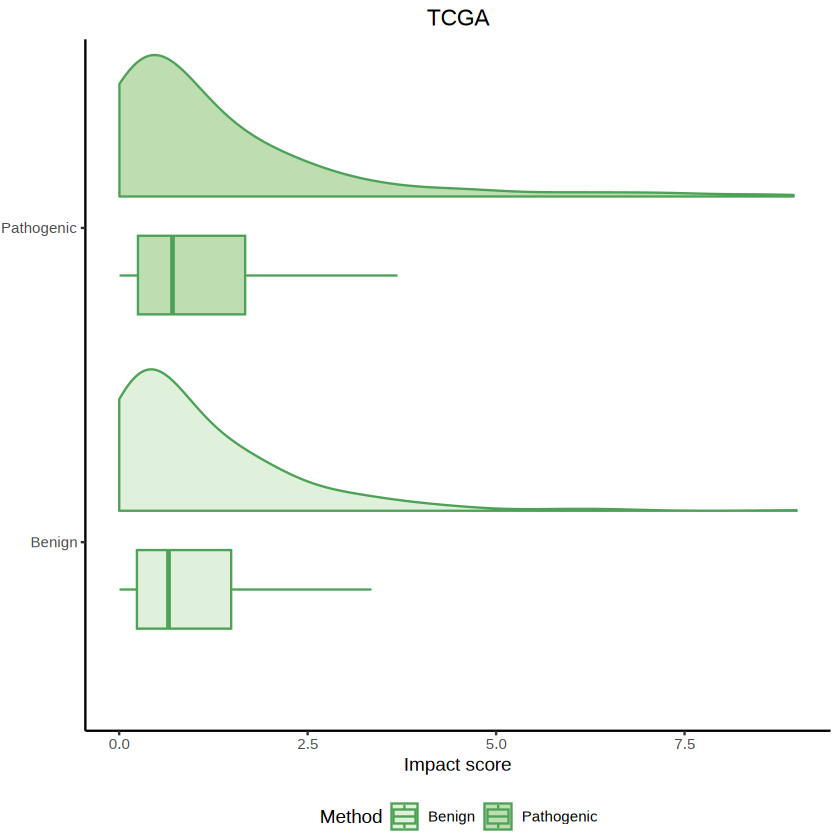

In [4]:
# %%R
# Load required libraries
library(ggplot2)
library(ggsignif)
library(readxl)
library(dplyr)
library(tidyr)
library(gghalves)
library(readr)
databases <- 'tcga_variants'
file_path <- paste0("../../results/variant/subgroup_disease_ornot/", databases, "/", databases, "_abs_diff.txt")
df <- read_tsv(file_path)

data_long <- df %>%
  select(`Benign`, `Pathogenic`) %>%
  gather(key = "Method", value = "Impact score")

# Remove NA and infinite values
data_long <- data_long %>%
  filter(!is.na(`Impact score`) & is.finite(`Impact score`))

p <- ggplot(data_long, aes(Method, `Impact score`, fill = Method)) +
  geom_half_violin(
    data = subset(data_long, `Impact score` <= 9.2),
    trim = TRUE, scale = "width",
    color = "#4ea258", width = 0.9,
    position = position_nudge(x = .1),
    side = 2, adjust = 2
  ) +
  geom_boxplot(
    data = subset(data_long, `Impact score` <= 9.2),
    width = .25, position = position_nudge(x = -0.15),
    outlier.shape = NA, color = "#4ea258"
  ) +
  scale_fill_manual(values = c("Benign" = "#dff1da", "Pathogenic" = "#bedeb2")) +
  theme_classic() +
  theme(
    legend.position = "bottom",
    plot.margin = unit(c(0.2, 0.2, 0, -0.4), "cm"),
    plot.title = element_text(hjust = 0.5)
  ) +
  labs(y = "Impact score", x = "", title = "TCGA") +
  coord_cartesian(ylim = c(0, 1)) +  # Set y-axis limits
  coord_flip()                       # Flip x and y axes

p